# You can run sapphire interactively in 3 simple steps:
1. import sapphire
2. define python dictionary of input parameters (see docs and below) 
3. sapphire.run(parameters) 

Soon there will be:
- a way to run from the command line "python -m sapphire parameters.json"-
- repeatedly run internally with built-in HMC/nested sampling functions
- the JAX version ported over for JIT (10x speed boost) and gradients (for both optimization and physical interpretation)

In [12]:
%matplotlib inline
import sys
# sys.path.insert(0, '/mnt/ceph/users/skoudmani/JAXProj/sapphire/')
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer as timer
import pandas as pd
from astropy.table import Table
from astropy.cosmology import Planck15

import importlib

import sapphire 

import multiprocess
print(multiprocess.cpu_count())

from astropy import units as u
s_to_yr = u.s.to('yr')

importlib.reload(sapphire)

128


<module 'sapphire' from '/mnt/ceph/users/vpandya/sapphire/sapphire/__init__.py'>

In [2]:
""" This is an optional feature we are using to downsample the # of halos we will model to speed up computation time """

# define a list of (Mlow,Mhigh,N) tuples with same bin definitions as Behroozi+19 relation
# we will only model N random halos within each of these z=0 Mvir mass bins to cut down on modeling time
# this list of tuples is an input runtime parameter for sapphire below (along with np.random.seed(#) for reproducibility) 
downsample_bins = np.arange(10.0,14.2,0.2) # note the masses are log10 mvir
print(downsample_bins)

# we will ask for 5 random halos per mass bin
downsample_defs = [(downsample_bins[i],downsample_bins[i+1],5) for i in range(len(downsample_bins)-1)]

downsample_defs

[10.  10.2 10.4 10.6 10.8 11.  11.2 11.4 11.6 11.8 12.  12.2 12.4 12.6
 12.8 13.  13.2 13.4 13.6 13.8 14. ]


[(10.0, 10.2, 5),
 (10.2, 10.399999999999999, 5),
 (10.399999999999999, 10.599999999999998, 5),
 (10.599999999999998, 10.799999999999997, 5),
 (10.799999999999997, 10.999999999999996, 5),
 (10.999999999999996, 11.199999999999996, 5),
 (11.199999999999996, 11.399999999999995, 5),
 (11.399999999999995, 11.599999999999994, 5),
 (11.599999999999994, 11.799999999999994, 5),
 (11.799999999999994, 11.999999999999993, 5),
 (11.999999999999993, 12.199999999999992, 5),
 (12.199999999999992, 12.399999999999991, 5),
 (12.399999999999991, 12.59999999999999, 5),
 (12.59999999999999, 12.79999999999999, 5),
 (12.79999999999999, 12.99999999999999, 5),
 (12.99999999999999, 13.199999999999989, 5),
 (13.199999999999989, 13.399999999999988, 5),
 (13.399999999999988, 13.599999999999987, 5),
 (13.599999999999987, 13.799999999999986, 5),
 (13.799999999999986, 13.999999999999986, 5)]

In [3]:
# set up a general parameters dict 

# try running new thermal_general model on same 656 TNG trees 
parameters = {'output_path':'/mnt/ceph/users/skoudmani/JAXProj/outputs/', # path where any output files should be saved (irrelevant if return_or_write=='return' below)
              
              ### runtime-related related parameters (you only need to vary tree_path) 
              
              'tree_type':'tng_sapphire', # type of merger trees / MAHs -- this determines what read_trees module gets loaded
              'tree_path':'/mnt/ceph/users/vpandya/sapphire/data/tng_trees_compactified_20subvolumes.npz', # either a directory containing tree files or path to single tree file itself 
              'halo_names':[], # optional for certain simulations -- list of halo names/IDs to process (default=empty=process all trees for given tree_type and tree_dir)
              'subvolumes':None, # for testing speed purposes, only work with trees from a single TNG subvolume 
              'num_readers':5, # irrelevant for tree_type='tng_sapphire'
              'num_writers':5, # irrelevant when return_or_write = 'return' (otherwise how many output writer tasks to start in parallel)
              'return_or_write':'return', # if 'return', return pandas dataframe (you should assign to a variable below); if 'write' then save dataframe to hdf5
              'min_root_mass':1e10, # relevant for tree_type ='tng' and 'tng_sapphire', not 'fire2' or 'fire2_pandya22'
              'max_root_mass':None, # relevant for tree_type=tng_sapphire -- halos above this z=0 Mvir will not be modeled (set to None or 0 to model everything)
              'downsample_defs':downsample_defs, # list of tuples (logMlow,logMhigh,N) such that N random halos will be chosen in each mass bin (None otherwise)
              'downsample_seed':999, # np.random.seed(#) to ensure reproducibility when downsampling to N random halos in each mass bin (None otherwise)
              'rtol':1e-5, # relative error tolerance for ODE solver (this controls error on exponent of state variables), should be 1e-3 or lower 
              'atol':1e-3, # absolute error tolerance for ODE solver (this controls early evolution when ICs close to 0), should be 1e-3 or lower 
              
              ### fixed physical model parameters (this just sets the overall physical model and associated fixed parameters) 
              
              'physical_model':'thermal_general_AGN', # name of physical model (and associated free parameter functional forms)
              'coolfunc':'wiersma09', # which cooling function to use (wiersma09, sd93, ploeckinger20)
              'alpha_n':-3/2., # slope of CGM density power law
              'alpha_T':0.0, # slope of CGM temperature power law 
              'tau_escape':1.0, # scales the halo outflow timescale tdyn=tau*Rvir/Vvir
              'f_recycle':0.4, # instantaneous stellar-->ISM recycling fraction 
              'e_wind_halo':1.0, # specific energy of halo wind relative to Ecgm/Mcgm                            
              'yZ':0.02, # metal yield of 1 SN per 100 Msun of stars formed (2 Msun / 100 Msun = 0.02 for 10 Msun of SN ejecta)
              'return_all':False, # whether to return only the ODE RHS for solver, or all properties at each time for outputting
              
              ### FREE PARAMETERS BELOW THIS LINE -- WE WILL VARY A SUBSET OF THESE 
              ### there are 4 physical parameters: mass, energy and metal loading factors, and the ISM depletion time
              ### each physical parameter has 4 hyperparameters describing a power law: normalization, slope, and the redshift dependences of those two
              ### the exact power law is X(Vvir,z) = A * (Vvir/125.)**(alpha0 + alphaz*(1+z)) * (1+z)**beta              
              
              'etaM_A':0.1, # normalization of power law for mass loading factor [prior range: 0.01 to 100]
              'etaM_alpha0':-0.5, # slope of power law for mass loading factor [prior range: -2 to 2]
              'etaM_alphaz':0.0, # this can be fixed to 0; redshift dependence of slope of power law for mass loading factor [prior range: -2 to 2]
              'etaM_beta':0.0, # this can be fixed to 0; redshift dependence of normalization of power law for mass loading factor [prior range: -2 to 2]
              'tdep_A':3.0, # [prior range: 0.01 to 10]
              'tdep_alpha0':-3.0, # [prior range: -2 to 2]
              'tdep_alphaz':0.0, # this can be fixed to 0 [prior range: -2 to 2]
              'tdep_beta':-0.7, # [prior range: -2 to 2]
              'etaE_A':0.5, # [prior range: 0.01 to 1]
              'etaE_alpha0':-0.5, # [prior range: -2 to 2]
              'etaE_alphaz':0.0, # this can be fixed to 0 [prior range: -2 to 2]
              'etaE_beta':0.0,   # this can be fixed to 0 [prior range: -2 to 2]
              'etaZ_A':0.5, # [prior range: 0.01 to 1]
              'etaZ_alpha0':0.0, # [prior range: -2 to 2]
              'etaZ_alphaz':0.0, # this can be fixed to 0 [prior range: -2 to 2]
              'etaZ_beta':0.0,# this can be fixed to 0 [prior range: -2 to 2]
              'f_bh':1.0e-4,
              'kappa_bh':1.0e-3} 



In [4]:
tstart = timer()
df_results = sapphire.run(parameters) # this is the only line you need, I just enclosed it in a timer for benchmarking
print('Finished in %s sec'%(timer()-tstart))


Finished in 53.974167454987764 sec


In [5]:
### the results are returned as a pandas dataframe 
# the row index is roothaloid and the columns are different physical properties 
# the entries are the time series of these physical properties for each halo 
df_results

,MZ_cgm,Zism,f_UV,log_Zcgm,NFW_vcirc,evir_halo,t_accrete,cosmic_age,MZdot_ism,Mdot_in_dm,...,Mdot_sfr,Eth_cgm,etaZ_ism,MZdot_yield,MZdot_in_halo,sol_nfev,sol_njev,sol_nlu,sol_success,sol_status
1123826638,"[66.40769999891589, 67.69910898216312, 69.0017...","[2.0000000000000003e-06, 2.300648447917429e-06...","[0.999863140689785, 0.9998574601542979, 0.9998...","[-3.9999999999999996, -3.9937763238593362, -3....","[30.729868562330633, 30.743296869528645, 30.75...","[1.1244032186303999e+46, 1.1257381499915075e+4...","[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[0.47273545495018104, 0.4743346249425185, 0.47...","[44.425591594593136, 38.7577905036814, 34.3851...","[2.3202271817273825, 2.322279842230776, 2.3243...",...,"[1.8798176129081114e-11, 1.8801613226102327e-1...","[6.823386783451998e+50, 2.5034143964113363e+51...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[3.759635225816223e-13, 3.7603226452204655e-13...","[8.054130145108524e-07, 8.096860050649859e-07,...","[1125.0, 1125.0, 1125.0, 1125.0, 1125.0, 1125....","[54.0, 54.0, 54.0, 54.0, 54.0, 54.0, 54.0, 54....","[226.0, 226.0, 226.0, 226.0, 226.0, 226.0, 226...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1123011124,"[103.09098908561829, 104.70901737409827, 106.3...","[2.0000000000000003e-06, 2.5411071655260784e-0...","[0.9999982561577893, 0.9999981747534815, 0.999...","[-4.0, -3.9945690037933574, -3.989190750853590...","[36.786443032715404, 36.79925149228221, 36.812...","[1.7342265714728013e+46, 1.7354243765568098e+4...","[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[0.3683760444781429, 0.36971448663452733, 0.37...","[74.47508622359939, 58.78839960406774, 48.5776...","[2.447390386765444, 2.447787557943683, 2.44818...",...,"[4.044067532791836e-11, 4.041261188789602e-11,...","[1.2024451997328969e+51, 3.902081684597204e+51...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[8.088135065583672e-13, 8.082522377579204e-13,...","[1.206327969226996e-06, 1.2114474509743332e-06...","[1069.0, 1069.0, 1069.0, 1069.0, 1069.0, 1069....","[59.0, 59.0, 59.0, 59.0, 59.0, 59.0, 59.0, 59....","[185.0, 185.0, 185.0, 185.0, 185.0, 185.0, 185...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1124729141,"[95.17372666551469, 98.79155181306105, 101.160...","[2.0000000000000003e-06, 2.074447471440964e-06...","[0.995551587144687, 0.9955267021372582, 0.9955...","[-4.0, -3.986532641507034, -3.9729578604795863...","[28.895332644853642, 28.914237931367563, 28.93...","[1.0913772342521724e+46, 1.0929210543585333e+4...","[inf, 0.24053537517700674, 0.13897870526771466...","[0.7296972374342306, 0.7318475804318911, 0.734...","[53.56574743533383, 4674.395272364128, 375.494...","[3.5248971631157464, 3.5247531122221925, 3.524...",...,"[1.4684030436746518e-11, 4.6062401181599104e-0...","[9.691226784451575e+50, 2.33946044028623e+53, ...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[2.9368060873493034e-13, 9.21248023631982e-09,...","[1.70868784721433e-06, 1.7159688386045424e-06,...","[972.0, 972.0, 972.0, 972.0, 972.0, 972.0, 972...","[58.0, 58.0, 58.0, 58.0, 58.0, 58.0, 58.0, 58....","[185.0, 185.0, 185.0, 185.0, 185.0, 185.0, 185...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1124728969,"[49.73338317896006, 49.992999919817606, 50.254...","[2.0000000000000003e-06, 2.2432608980251704e-0...","[0.9999593545516584, 0.9999574553359306, 0.999...","[-4.0, -3.9984730526784755, -3.996943885211073...","[26.424689614910815, 26.428583523459732, 26.43...","[9.973264107522882e+45, 9.974379803011763e+45,...","[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[0.41580186222766724, 0.41726203338095175, 0.4...","[34.651473487475286, 30.956369222357086, 27.97...","[0.6633888302439996, 0.6634990856023305, 0.663...",...,"[1.6670034998460258e-11, 1.6645321014168378e-1...","[4.926650405526788e+50, 9.065845853015332e+50,...","[

In [6]:
# suppose the only thing we cared about was predicting the z=0 SMHM relation for a given set of model parameters

# use list comprehension to store final z=0 Mvir and Mstar of each halo (i.e., of each row aka roothaloid of df_filtered)
# here we are iterating over each row which is a distinct roothaloid
# the values of every column for a given row/roothaloid are numpy arrays of time series of that property going from high-z to z~0

z0_Mvir = np.array([df_results.iloc[irow]['Mvir'][-1] for irow in range(len(df_results))])
z0_Mstar = np.array([df_results.iloc[irow]['M_star'][-1] for irow in range(len(df_results))])
z0_Mbh = np.array([df_results.iloc[irow]['M_BH'][-1] for irow in range(len(df_results))])
z0_Mdotbh = np.array([df_results.iloc[irow]['Mbh_dot'][-1] for irow in range(len(df_results))])

Text(0, 0.5, '$\\log_{10}M_{\\rm star}/M_{\\rm vir}$ (z=0)')

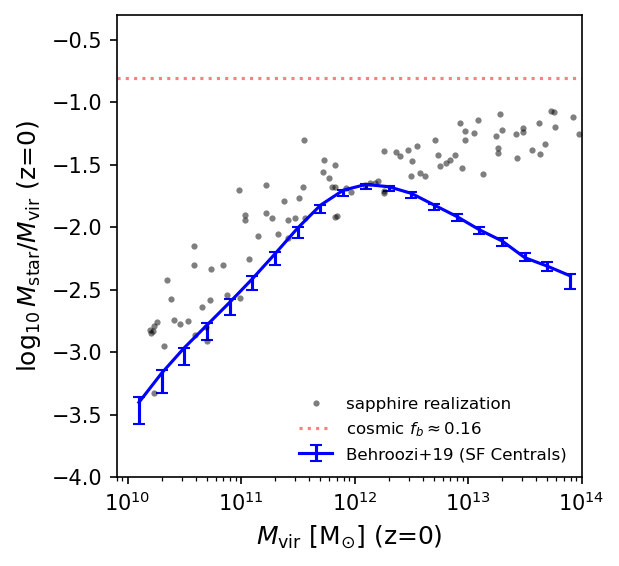

In [26]:
# overplot the z=0 SMHM relation of this model vs the Behroozi SMHM relation for centrals at z=0

fig, ax = plt.subplots(1,figsize=(4,4),dpi=150)

### plot Behroozi+19 relation including only central SF galaxies/halos
# first read in Behroozi+19 UniverseMachine DR1 Median SMHM relation at z=0  
# and discard bins below logmvir<10.5 due to Bolshoi-Planck resolution limit (not sure why he included these)
tum = Table.read('smhm_a1.002312.dat',format='ascii')
tum = tum[(tum['HM(0)']>=10.0) & (tum['HM(0)']<=14.0)]

ax.errorbar(10**tum['HM(0)'],tum['Med_Cen_SF(7)'],yerr=[np.abs(tum['Err-(9)']),np.abs(tum['Err+(8)'])],fmt='b-',capsize=3,label='Behroozi+19 (SF Centrals)')

# plot our model's realization
ax.plot(z0_Mvir,np.log10(z0_Mstar/z0_Mvir),'k.',alpha=0.5,mec='none',label='sapphire realization')

ax.set_xscale('log')
ax.set_xlim(None,1e14)
ax.set_ylim(-4,-0.3)

ax.axhline(np.log10(Planck15.Ob0/Planck15.Om0),color='r',ls=':',alpha=0.5,label=r'cosmic $f_b\approx0.16$')

ax.legend(loc='lower right',fontsize=8,fancybox=True,framealpha=0)

ax.set_xlabel(r'$M_{\rm vir}$ [M$_{\odot}$] (z=0)',fontsize=12)
ax.set_ylabel(r'$\log_{10}M_{\rm star}/M_{\rm vir}$ (z=0)',fontsize=12)


#### You can see that since we don't have AGN yet, the model overpredicts the SMHM relation in massive group/cluster halos
#### Other observable constraints can also be folded in

Text(0, 0.5, 'Mdot_BH [Msun/yr]')

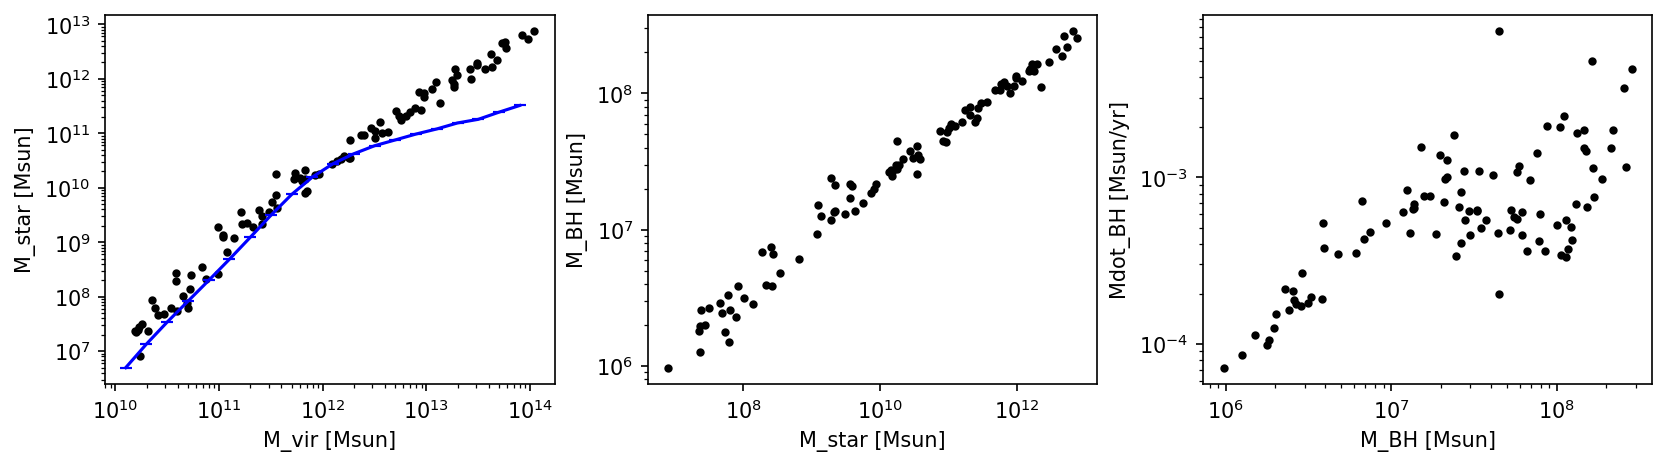

In [28]:
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(11,3),dpi=150,constrained_layout=True)

axes[0].loglog(z0_Mvir,z0_Mstar,'k.')
axes[0].errorbar(10**tum['HM(0)'],10**tum['HM(0)']*10**tum['Med_Cen_SF(7)'],yerr=[np.abs(tum['Err-(9)']),np.abs(tum['Err+(8)'])],fmt='b-',capsize=3,label='Behroozi+19 (SF Centrals)')
axes[0].set_xlabel('M_vir [Msun]')
axes[0].set_ylabel('M_star [Msun]')

axes[1].loglog(z0_Mstar,z0_Mbh,'k.')
axes[1].set_xlabel('M_star [Msun]')
axes[1].set_ylabel('M_BH [Msun]')

axes[2].loglog(z0_Mbh,z0_Mdotbh/s_to_yr,'k.')
axes[2].set_xlabel('M_BH [Msun]')
axes[2].set_ylabel('Mdot_BH [Msun/yr]')